# Choosing the right measure

This tutorial explains the choices `NormalizedMI` offers and, more importantly,
*when* to use them. We will cover

1. the **normalization method** (`normalize_method`), which turns the mutual
   information into a normalized quantity in $[0, 1]$, and
2. the **invariant measure** (`invariant_measure`), which controls how the
   $k$-nearest-neighbor radii are rescaled.

Along the way we highlight the central assumption behind the
Kraskov–Stögbauer–Grassberger (KSG) estimator that NorMI builds on: the data
must be **locally uniformly distributed**, i.e. the density should be roughly
constant on the scale of the nearest neighbors. When this assumption is
violated — most notably for heavy-tailed data such as log-normal variables
analyzed on a linear scale — the estimate degrades. We show how to detect this
and how to fix it, either by **transforming the variable** or by switching to a
**median-based invariant measure**.

For the theoretical background, see the NorMI publication
([arXiv:2405.04980](https://arxiv.org/abs/2405.04980)).


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from normi import NormalizedMI

rng = np.random.default_rng(42)
plt.rcParams['figure.figsize'] = (4, 3)
plt.rcParams['figure.dpi'] = 120

## 1. The normalization method

The mutual information $I(X, Y)$ is unbounded from above, which makes it hard to
compare different pairs of variables. NorMI therefore divides it by an entropy
term to obtain a value in $[0, 1]$:

$$
\text{NMI}(X, Y) = \frac{I(X, Y)}{\text{norm}\big(H(X), H(Y), H(X, Y)\big)} .
$$

The available `normalize_method` choices are:

| method | denominator | interpretation |
| --- | --- | --- |
| `'joint'` | $H(X, Y)$ | fraction of the *joint* entropy that is shared |
| `'max'` | $\max\big(H(X), H(Y)\big)$ | strictest, most conservative |
| `'min'` | $\min\big(H(X), H(Y)\big)$ | most permissive |
| `'arithmetic'` | $\tfrac{1}{2}\big(H(X) + H(Y)\big)$ | mean of marginals |
| `'geometric'` | $\sqrt{H(X)\,H(Y)}$ | **default**, symmetric, behaves like a correlation coefficient |

**Rule of thumb**

- Use the default `'geometric'` for a correlation-coefficient-like quantity that
  is symmetric in $X$ and $Y$.
- Use `'max'` if you want a conservative lower bound on the shared information.
- Use `'joint'` if you care about the share of the *total* information that is
  redundant.

All methods agree on the extremes (0 for independence, 1 for a deterministic
relationship); they differ only in how they scale partial dependence. Let us
verify this on two correlated variables.

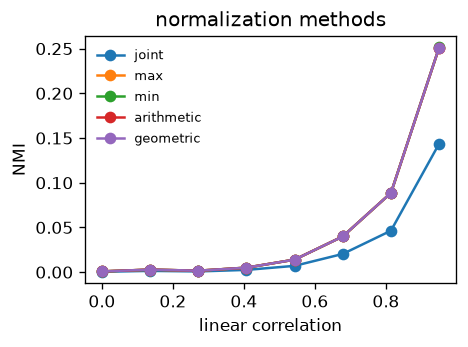

In [2]:
# build two correlated variables with a tunable correlation
def correlated(n, corr):
    z = rng.normal(size=n)
    x = rng.normal(size=n)
    y = corr * z + np.sqrt(1 - corr**2) * rng.normal(size=n)
    x = corr * z + np.sqrt(1 - corr**2) * x
    return np.column_stack([x, y])

corrs = np.linspace(0.0, 0.95, 8)
methods = ['joint', 'max', 'min', 'arithmetic', 'geometric']

results = {m: [] for m in methods}
for c in corrs:
    X = correlated(5000, c)
    for m in methods:
        nmi = NormalizedMI(normalize_method=m, verbose=False).fit(X)
        results[m].append(nmi.nmi_[0, 1])

for m in methods:
    plt.plot(corrs, results[m], marker='o', label=m)
plt.xlabel('linear correlation')
plt.ylabel('NMI')
plt.legend(frameon=False, fontsize=8)
plt.title('normalization methods')
plt.tight_layout()
plt.show()

All methods increase monotonically with the dependence and bracket each
other as expected (`min` $\geq$ `geometric` $\approx$ `arithmetic` $\geq$ `max`
$\geq$ `joint`). The choice is therefore mostly a matter of interpretation, not
of detecting dependence.

## 2. The invariant measure and the constant-density assumption

The KSG estimator infers entropies from the distances to the $k$-th nearest
neighbor of each sample. Implicitly it assumes that the density is **locally
constant**: within the small ball that contains the $k$ nearest neighbors, the
points should look as if they were drawn from a *uniform* distribution. NorMI
makes the estimate invariant under rescaling of each variable by normalizing the
neighbor radii. The `invariant_measure` parameter selects how:

- `'radius'` — divide by the **mean** $k$-nn radius.
- `'volume'` — divide by the **mean** $k$-nn volume (default).
- `'volume_stable'` — a numerically stabilized variant of `'volume'` for
  high-dimensional features.
- `'radius_median'` / `'volume_median'` — like above, but using the **median**
  instead of the mean (robust against outliers, see below).
- `'kraskov'` — no rescaling (the original KSG normalization).

For well-behaved, roughly uniform data the mean-based measures are the natural
choice. The trouble starts when the local density is *not* constant.

### When the assumption breaks: heavy tails / outliers

Consider a **log-normal** variable. On a linear scale a few samples sit far out
in the tail. These outliers dominate the *mean* radius, the mean volume is
hugely overestimated, and the entropy estimate can even become meaningless
(in extreme cases negative). Let us look at the raw data first.

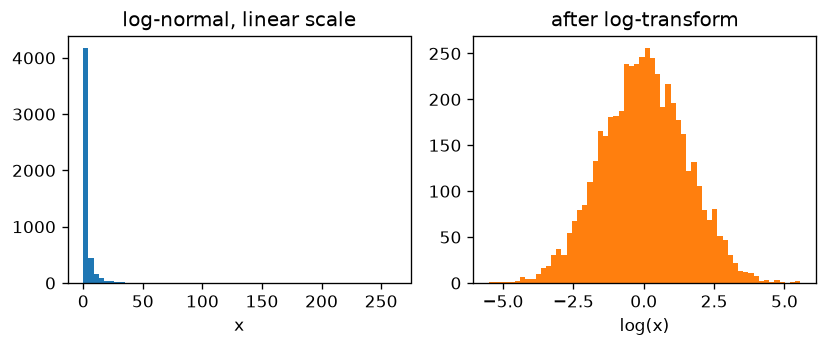

In [3]:
x_lognorm = rng.lognormal(mean=0, sigma=1.5, size=5000)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].hist(x_lognorm, bins=60, color='C0')
axes[0].set_title('log-normal, linear scale')
axes[0].set_xlabel('x')
axes[1].hist(np.log(x_lognorm), bins=60, color='C1')
axes[1].set_title('after log-transform')
axes[1].set_xlabel('log(x)')
plt.tight_layout()
plt.show()

On the linear scale (left) the bulk of the data is squeezed into a tiny
range while a long tail stretches far to the right — the density is very far from
constant. After a `log` transform (right) the variable is Gaussian and nicely
spread out: locally uniform on the relevant scale. This is exactly the regime
the estimator was designed for.

### Two correlated log-normal variables

We now build two variables that share information *through their logarithms* and
compare three strategies:

1. **mean-based measure on the raw (linear) data** — assumption violated,
2. **median-based measure on the raw data** — robust workaround,
3. **mean-based measure on the log-transformed data** — the recommended fix.

In [4]:
# latent Gaussian dependence, then exponentiate -> correlated log-normals
z = rng.normal(size=5000)
g1 = 0.9 * z + np.sqrt(1 - 0.9**2) * rng.normal(size=5000)
g2 = 0.9 * z + np.sqrt(1 - 0.9**2) * rng.normal(size=5000)

X_linear = np.column_stack([np.exp(1.5 * g1), np.exp(1.5 * g2)])
X_log = np.log(X_linear)  # == 1.5 * g1, 1.5 * g2 up to a constant

nmi_mean_linear = NormalizedMI(
    invariant_measure='volume', verbose=False,
).fit(X_linear).nmi_[0, 1]

nmi_median_linear = NormalizedMI(
    invariant_measure='volume_median', verbose=False,
).fit(X_linear).nmi_[0, 1]

nmi_mean_log = NormalizedMI(
    invariant_measure='volume', verbose=False,
).fit(X_log).nmi_[0, 1]

print(f'mean   measure, linear data : NMI = {nmi_mean_linear:.3f}')
print(f'median measure, linear data : NMI = {nmi_median_linear:.3f}')
print(f'mean   measure, log data    : NMI = {nmi_mean_log:.3f}')

mean   measure, linear data : NMI = 0.953
median measure, linear data : NMI = 0.124
mean   measure, log data    : NMI = 0.158


The dependence is identical in all three cases (the log is a monotonic,
per-variable transform, so the true mutual information is unchanged). The two
fixes agree on a moderate NMI, which is the correct answer for a latent
correlation of $0.9$. The mean-based estimate on the **raw linear data**, in
contrast, is **spuriously inflated** — it reports an almost perfect dependence.
The handful of extreme outliers blow up the mean neighbor volume, the entropy
estimates become unreliable, and the two variables wrongly look nearly
deterministic. Both fixes remove this artifact:

- the **median-based** invariant measure (`volume_median` / `radius_median`)
  ignores the inflating effect of the outliers, and
- the **log-transform** restores local uniformity so even the default mean-based
  measure works.

**Recommendation:** prefer transforming the variables so that each is roughly
locally uniform (this is the most principled fix). When you cannot or do not want
to transform — e.g. in an automated pipeline over many heterogeneous features —
use the median-based invariant measures as a robust default.

### Quick summary

| situation | recommended setting |
| --- | --- |
| general use, well-behaved data | `normalize_method='geometric'`, `invariant_measure='volume'` |
| conservative lower bound on shared info | `normalize_method='max'` |
| heavy-tailed / outlier-prone features | transform variables, or `invariant_measure='volume_median'` |
| very high-dimensional features | `invariant_measure='volume_stable'` |
